In [41]:
import numpy as np
import quimb
import quimb.tensor as qtn

# Matrix Singular Value Decomposition Example:


In [42]:
M = np.random.rand(4,4)
print(M)


[[0.30052068 0.91375873 0.86069985 0.67084286]
 [0.61970229 0.71061892 0.6254685  0.93870902]
 [0.34084721 0.26308368 0.13485353 0.5979161 ]
 [0.43704597 0.20165744 0.30954539 0.68241232]]


In [43]:
u, s, v= np.linalg.svd(M)
print('The matrix U is')
print(u)
print('--------------------------------')
print('The matrix S is')
print(np.diag(s))
print('--------------------------------')
print('The matrix V is')
print(v)

The matrix U is
[[-0.60743886  0.70781271  0.05411297  0.35649822]
 [-0.63849338 -0.16523937 -0.13785143 -0.73893108]
 [-0.30258785 -0.45445005 -0.67965894  0.48987699]
 [-0.3630218  -0.5149488   0.71842362  0.29480572]]
--------------------------------
The matrix S is
[[2.29608282 0.         0.         0.        ]
 [0.         0.58283289 0.         0.        ]
 [0.         0.         0.12390166 0.        ]
 [0.         0.         0.         0.06866163]]
--------------------------------
The matrix V is
[[-0.36584795 -0.50590074 -0.46834408 -0.6251988 ]
 [-0.46263892  0.5249295   0.48929644 -0.52057972]
 [ 0.10620936 -0.66540952  0.73512826 -0.07440557]
 [-0.80052488 -0.16044822  0.02879692  0.57670359]]


In [44]:
rs=np.zeros((4, 4))
for  i in range(len(np.diag(s))-1):
     for j in range(len(np.diag(s)[i])):
         if np.diag(s)[i][j]!=0:
            rs[i][j]=np.diag(s)[i][j]

print(rs)

[[2.29608282 0.         0.         0.        ]
 [0.         0.58283289 0.         0.        ]
 [0.         0.         0.12390166 0.        ]
 [0.         0.         0.         0.        ]]


In [45]:
rm= np.dot(u, np.dot(rs, v))
print(rm)

[[0.32011573 0.91768614 0.85999497 0.65672645]
 [0.57908669 0.70247839 0.62692955 0.96796878]
 [0.36777346 0.26848048 0.13388493 0.57851824]
 [0.45325006 0.2049052  0.30896249 0.67073877]]


In [46]:
distmat=rm-M
distant=(np.linalg.norm(distmat))**2
print(f'Distant between two matrices:{distant}.')
print(f'Squared truncated value:{s[3]**2}')

Distant between two matrices:0.004714418803046629.
Squared truncated value:0.0047144188030466385


# MPS demonstration:

## Building an MPS

We take a 3-qubit quantum state, i.e., a numpy array with 8 entries.

In [47]:
n = 3
psi = np.random.rand(2**n)
print(psi)
psi = psi / np.linalg.norm(psi)  # random, normalized state vector
psi = np.reshape(psi, (2, 2, 2))
psi.shape
psi

[0.19104944 0.11441944 0.73334682 0.23543023 0.89281005 0.5494999
 0.34034742 0.20633578]


array([[[0.13859135, 0.08300231],
        [0.53198547, 0.17078612]],

       [[0.64766351, 0.39861898],
        [0.2468953 , 0.14968039]]])

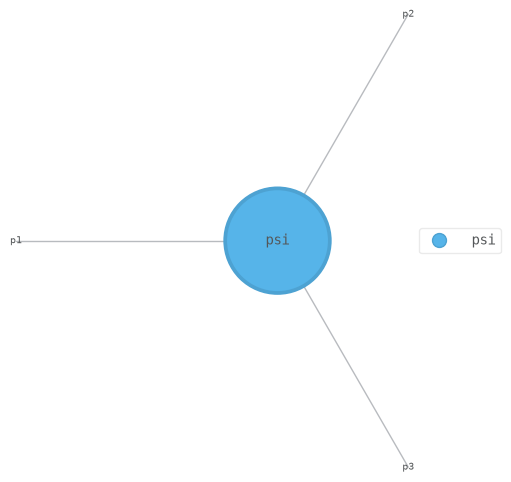

In [48]:
T_psi=qtn.Tensor(psi, inds=['p1', 'p2', 'p3'], tags='psi')
T_psi.draw(color=['psi'])

(2, 2)


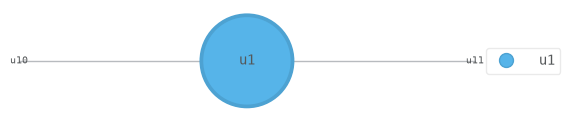

In [49]:
# reshape vector to matrix
psi = np.reshape(psi, (2, 2**(2)))
# SVD to split off first site
U1, Lambda1, Vd1 = np.linalg.svd(psi, full_matrices=False)
Us = []
Us.append(U1)
T_u1=qtn.Tensor(U1, inds=['u10', 'u11'], tags='u1' )
print(U1.shape)
T_u1.draw(color=['u1'])


In [50]:
psi_remainder1 = np.diag(Lambda1) @ Vd1
print(psi_remainder1.shape)                # mu1 (s2 s3)

(2, 4)


(4, 2)
(2, 2, 2)


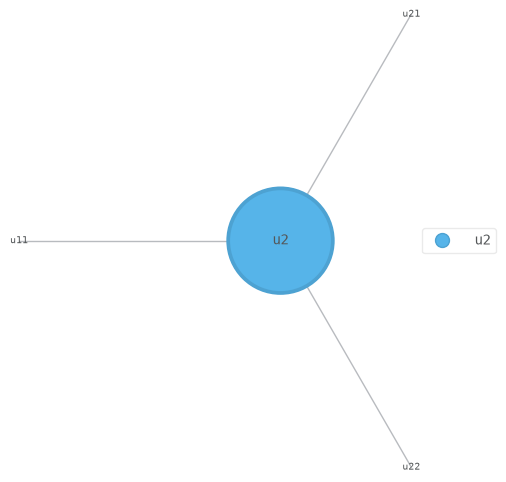

In [51]:
psi_remainder1 = np.reshape(psi_remainder1, (2**2, 2**1))  # (mu1 s2), s3
U2, Lambda2, Vd2 = np.linalg.svd(psi_remainder1, full_matrices=False)
print(U2.shape)
U2 = np.reshape(U2, (2, 2,2))
Us.append(U2)
print(U2.shape)
T_u2=qtn.Tensor(U2, inds=['u11', 'u21', 'u22'], tags='u2' )
T_u2.draw(color=['u2'])

(2, 2)


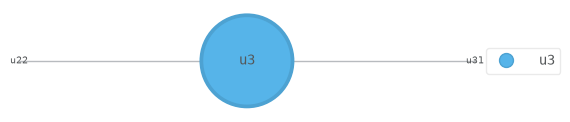

In [52]:
psi_remainder3 = np.diag(Lambda2) @ Vd2
print(psi_remainder3.shape)
Us.append(psi_remainder3)
T_u3=qtn.Tensor(psi_remainder3, inds=['u22', 'u31'], tags='u3' )
T_u3.draw(color=['u3'])

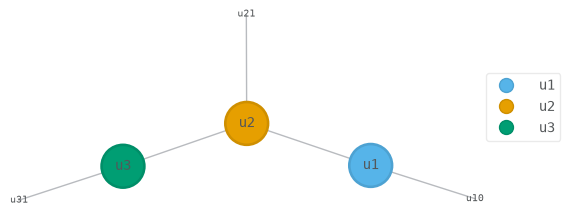

In [53]:
MPS_psi=(T_u1
    & T_u2
    & T_u3
    )
MPS_psi.draw(color=['u1', 'u2', 'u3'])

## Bond Dimension and Fidelity for Arbitrary States

In [54]:
n = 12
bond_dim = 10000

psi = np.random.rand(*[2]*n)
psi = psi/np.linalg.norm(psi)
mps = qtn.MatrixProductState.from_dense(psi, dims=[2] * n, max_bond=bond_dim)

[t.shape for t in mps.tensors]

[(2, 2),
 (2, 2, 4),
 (4, 2, 8),
 (8, 2, 16),
 (16, 2, 32),
 (32, 2, 64),
 (64, 2, 32),
 (32, 2, 16),
 (16, 2, 8),
 (8, 2, 4),
 (4, 2, 2),
 (2, 2)]

In [55]:
psi_mps = mps.to_dense().reshape([2] * n)
fidelity = abs(np.vdot(psi.ravel(), psi_mps.ravel()))**2
print('The fidelity of the built mps is:' ,fidelity)

The fidelity of the built mps is: 1.0000000000000036


In [56]:
n = 12
bond_dim = 5

psi = np.random.rand(*[2]*n)
psi = psi/np.linalg.norm(psi)
mps = qtn.MatrixProductState.from_dense(psi, dims=[2] * n, max_bond=bond_dim)

[t.shape for t in mps.tensors]

[(2, 2),
 (2, 2, 4),
 (4, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 4),
 (4, 2, 2),
 (2, 2)]

In [57]:

psi_mps = mps.to_dense().reshape([2] * n)
fidelity = abs(np.vdot(psi.ravel(), psi_mps.ravel()))**2
print('The fidelity of the built mps is:' ,fidelity)

The fidelity of the built mps is: 0.5917266223900159


## States theat already follows AREA LAW 

In [58]:
binary = '01'*6
psi = qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)
dense = psi.to_dense()
for chi in [1, 2, 4, 8]:
    mps_chi = qtn.MatrixProductState.from_dense(dense, dims=[2]*n, max_bond=chi)
    print('bond dim:', chi, 'Fidelity:', abs(np.vdot(dense.ravel(), mps_chi.to_dense().ravel()))**2)


bond dim: 1 Fidelity: 1.0
bond dim: 2 Fidelity: 1.0
bond dim: 4 Fidelity: 1.0
bond dim: 8 Fidelity: 1.0


In [59]:
psi

MatrixProductState(tensors=12, indices=23, L=12, max_bond=1)

## Building MPS of Known States

You can automatically call mps(s) from quimb's built-in functions.

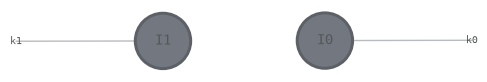

In [60]:
binary='00'
p=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)
p.draw()

Creating a bell state with MPS:

In [61]:
binary='00' #state you want to prepare
n=len(binary)
p=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)

p.to_dense()


array([[1.],
       [0.],
       [0.],
       [0.]])

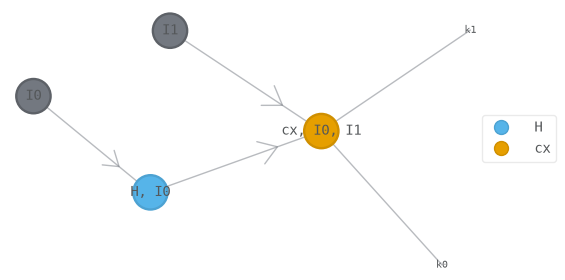

array([[0.70710678+0.j],
       [0.        +0.j],
       [0.        +0.j],
       [0.70710678+0.j]])

In [62]:
H = quimb.hadamard()
cx= quimb.controlled('x')

p.gate_(H, 0, tags='H', contract=False)
p.gate_(cx, (0,1),tags='cx', contract=False)
p.draw(color=['H', 'cx'])
p.to_dense()


## Expectation of H-gate with 100 qubit initial state

In [63]:
binary='0'*100
H = quimb.hadamard()
p=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)
p.left_canonize()

q=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)
q.right_canonize()
q.gate_(H, 50, tags='H', contract=False)


(p & q)^...



np.complex128(0.7071067811865475+0j)

We just did a expectation value calculation with 100 qubits.